In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("ecommerce_data.csv")

In [6]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

In [7]:
df["Gross_Sales"] = df["Quantity"] * df["Unit_Price"]
df["Discount_Amount"] = df["Gross_Sales"] * df["Discount"]
df["Net_Sales"] = df["Gross_Sales"] - df["Discount_Amount"]

In [8]:
df.head()

,Order_ID,Order_Date,Customer,City,Category,Product,Quantity,Unit_Price,Discount,Payment,Rating,Gross_Sales,Discount_Amount,Net_Sales
0,1001,2026-01-05,Amit,Pune,Electronics,Laptop,1,55000,0.05,UPI,5,55000,2750.0,52250.0
1,1002,2026-01-07,Sneha,Mumbai,Electronics,Headphones,2,2500,0.10,Card,4,5000,500.0,4500.0
2,1003,2026-01-12,Rahul,Delhi,Furniture,Chair,4,3500,0.05,Cash,4,14000,700.0,13300.0
3,1004,2026-01-18,Priya,Pune,Electronics,Keyboard,2,1800,0.00,UPI,5,3600,0.0,3600.0
4,1005,2026-02-03,Vikas,Mumbai,Electronics,Laptop,2,55000,0.08,Card,5,110000,8800.0,101200.0


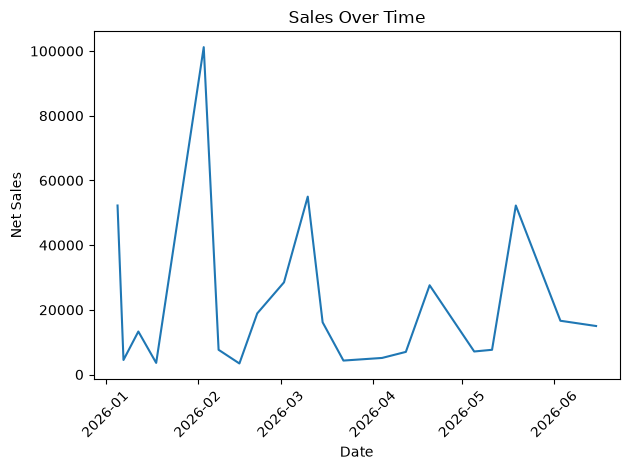

In [13]:
plt.plot(df["Order_Date"], df["Net_Sales"])

plt.xlabel("Date")
plt.ylabel("Net Sales")
plt.title("Sales Over Time")

plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("charts/sales_over_time.png")


In [16]:
category_sales = (
    df.groupby("Category")["Net_Sales"]
        .sum()
        .sort_values(ascending=False)
)

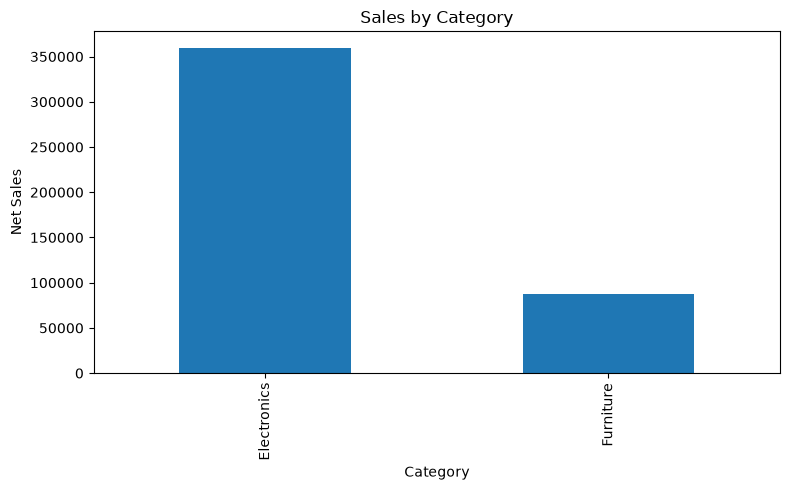

In [18]:
category_sales.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("charts/category_sales.png")

In [19]:
city_sales = (
    df.groupby("City")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)

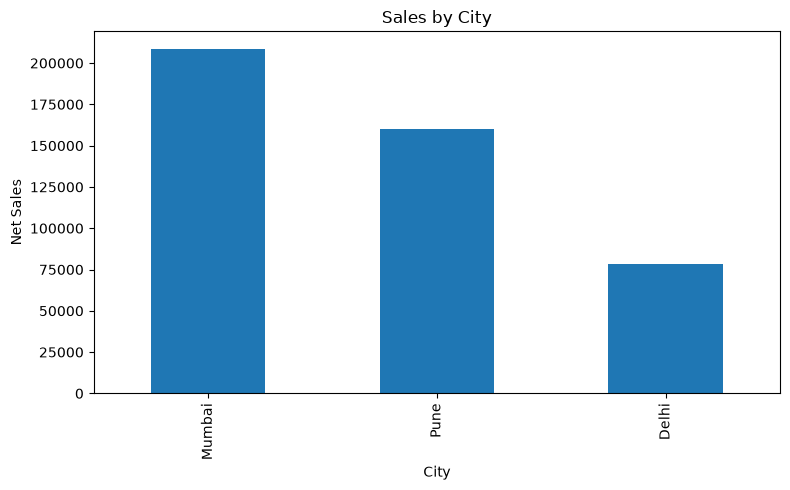

In [20]:
city_sales.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("charts/city_sales.png")

In [21]:
product_sales = (
    df.groupby("Product")["Net_Sales"]
      .sum()
      .sort_values(ascending=False)
)

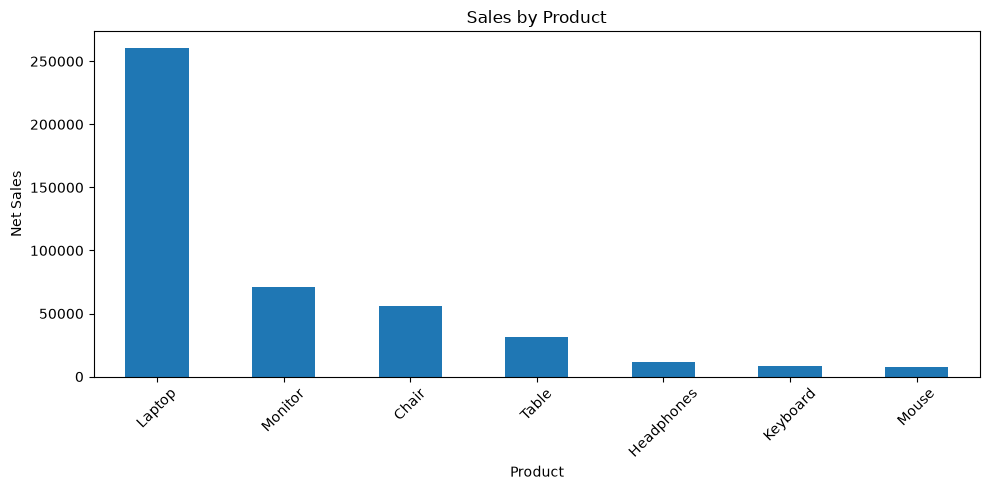

In [23]:
product_sales.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Sales by Product")
plt.xlabel("Product")
plt.ylabel("Net Sales")

plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("charts/product_sales.png")

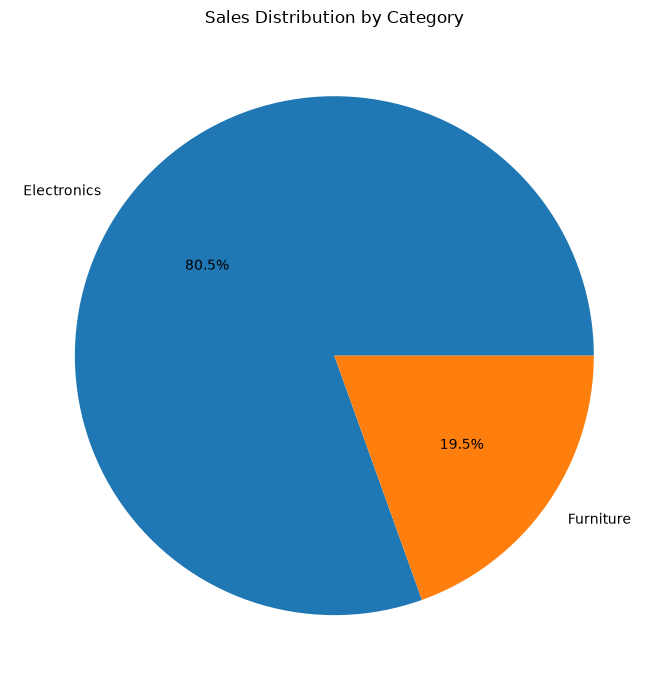

In [25]:
category_sales.plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7, 7)
)

plt.title("Sales Distribution by Category")
plt.ylabel("")

plt.tight_layout()
plt.savefig("charts/category_distribution.png")

In [26]:
df["Month"] = df["Order_Date"].dt.to_period("M")

In [27]:
monthly_sales = (
    df.groupby("Month")["Net_Sales"]
      .sum()
)

In [28]:
monthly_sales.index = monthly_sales.index.to_timestamp()

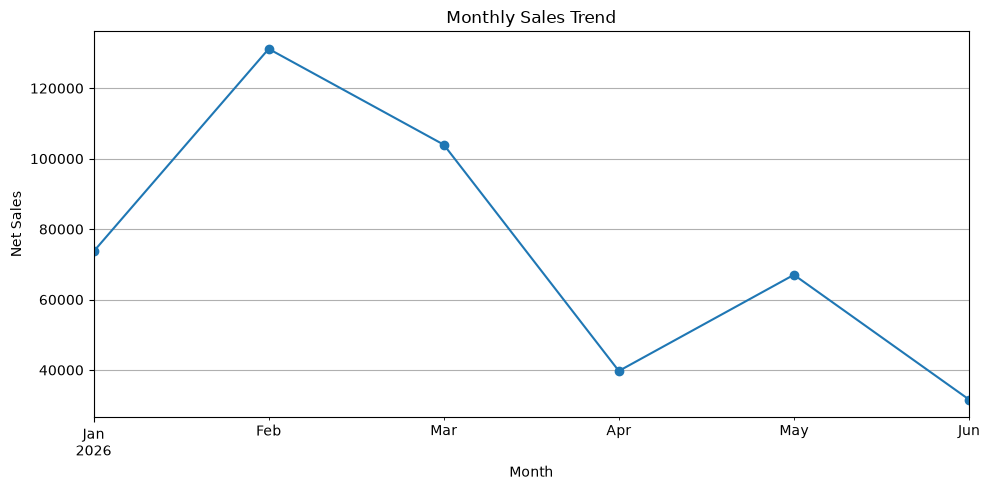

In [30]:
monthly_sales.plot(
    kind="line",
    marker="o",
    figsize=(10, 5)
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Net Sales")

plt.grid(True)

plt.tight_layout()
plt.savefig("charts/monthly_sales_trend.png")

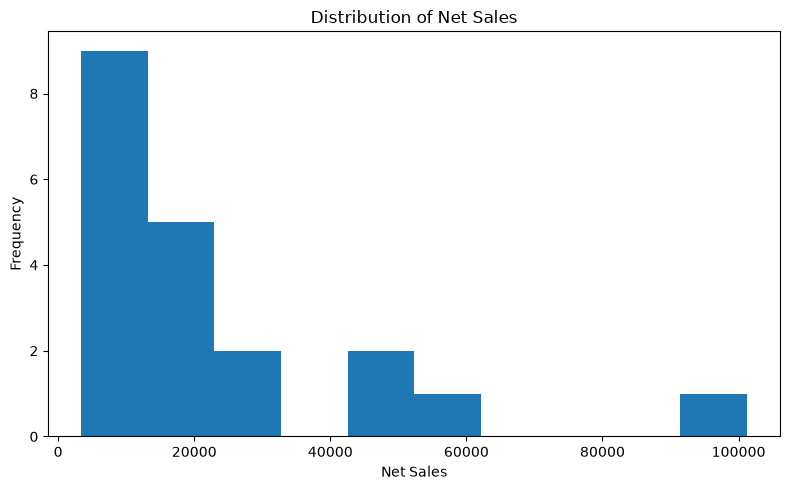

In [32]:
plt.figure(figsize=(8, 5))

plt.hist(
    df["Net_Sales"],
    bins=10
)

plt.title("Distribution of Net Sales")
plt.xlabel("Net Sales")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig("charts/sales_distribution.png")

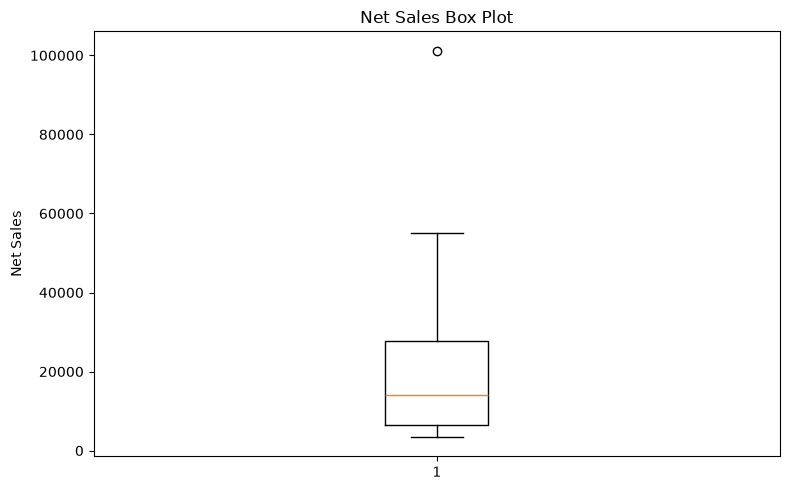

In [33]:
plt.figure(figsize=(8, 5))

plt.boxplot(df["Net_Sales"])

plt.title("Net Sales Box Plot")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("charts/sales_boxplot.png")

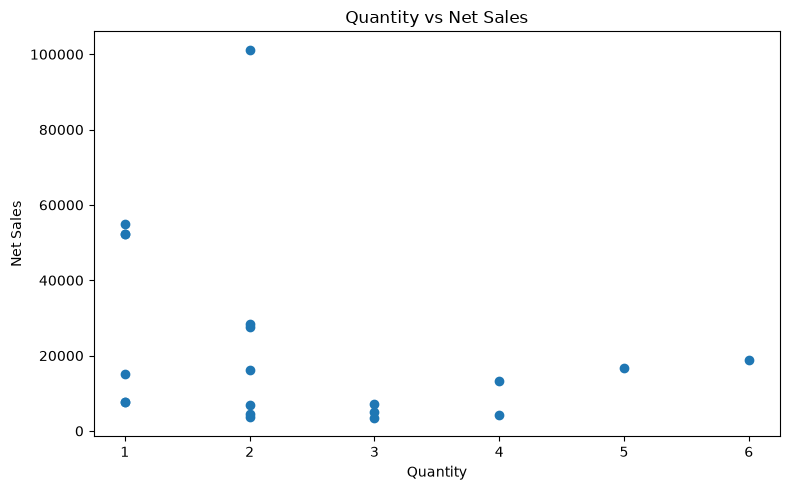

In [35]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Quantity"],
    df["Net_Sales"]
)

plt.title("Quantity vs Net Sales")
plt.xlabel("Quantity")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("charts/quantity_vs_sales.png")

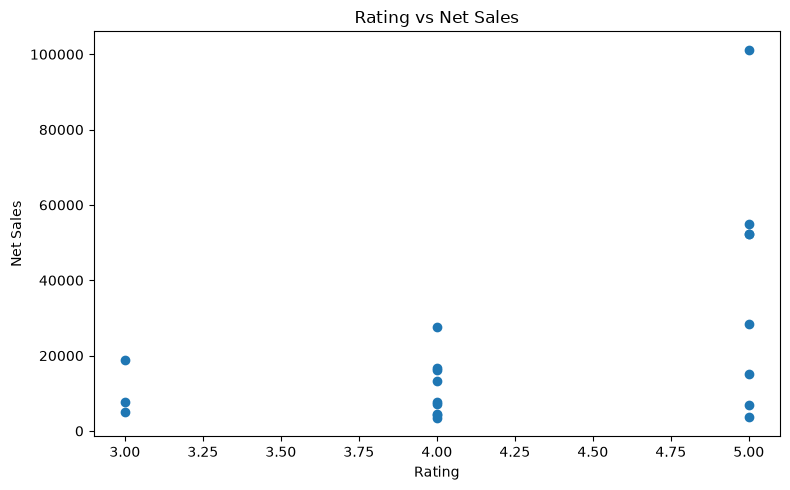

In [36]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Rating"],
    df["Net_Sales"]
)

plt.title("Rating vs Net Sales")
plt.xlabel("Rating")
plt.ylabel("Net Sales")

plt.tight_layout()
plt.savefig("charts/rating_vs_sales.png")

In [38]:
numeric_columns = [
    "Quantity",
    "Unit_Price",
    "Discount",
    "Rating",
    "Net_Sales"
]

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
            Quantity  Unit_Price  Discount    Rating  Net_Sales
Quantity    1.000000   -0.506688  0.266990 -0.514141  -0.282904
Unit_Price -0.506688    1.000000 -0.158237  0.579201   0.903814
Discount    0.266990   -0.158237  1.000000 -0.618951  -0.028247
Rating     -0.514141    0.579201 -0.618951  1.000000   0.502864
Net_Sales  -0.282904    0.903814 -0.028247  0.502864   1.000000


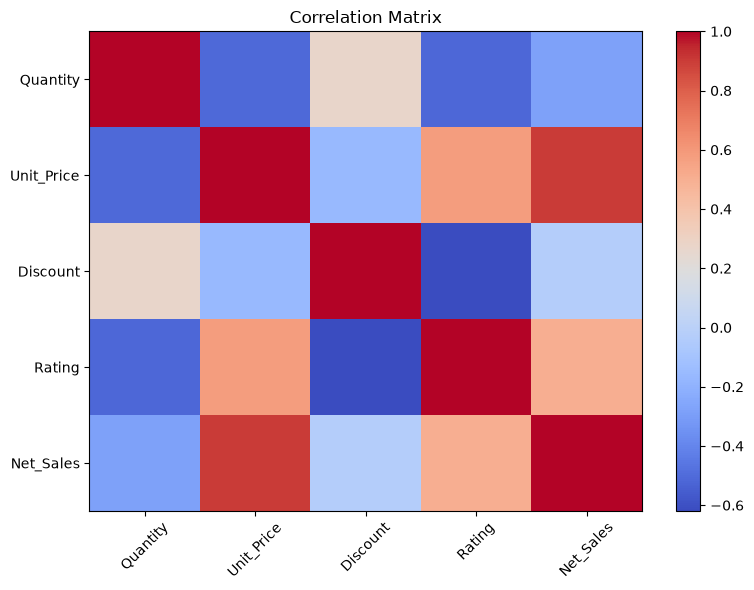

In [39]:
plt.figure(figsize=(8, 6))

plt.imshow(
    correlation,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.savefig("charts/correlation_matrix.png")

In [40]:
print("\n========== EDA SUMMARY ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nNumeric Summary:")
print(
    df[
        [
            "Quantity",
            "Unit_Price",
            "Discount",
            "Rating",
            "Net_Sales"
        ]
    ].describe()
)

print("\nMissing Values:")
print(df.isna().sum())

print("\nCorrelation:")
print(correlation)


========== EDA SUMMARY ==========

Dataset Shape:
(20, 15)

Numeric Summary:
        Quantity    Unit_Price   Discount    Rating      Net_Sales
count  20.000000     20.000000  20.000000  20.00000      20.000000
mean    2.400000  15775.000000   0.055500   4.25000   22358.500000
std     1.429022  20629.051436   0.035314   0.71635   25032.120423
min     1.000000   1200.000000   0.000000   3.00000    3420.000000
25%     1.000000   2500.000000   0.050000   4.00000    6532.500000
50%     2.000000   6000.000000   0.050000   4.00000   14150.000000
75%     3.000000  15000.000000   0.085000   5.00000   27825.000000
max     6.000000  55000.000000   0.100000   5.00000  101200.000000

Missing Values:
Order_ID           0
Order_Date         0
Customer           0
City               0
Category           0
Product            0
Quantity           0
Unit_Price         0
Discount           0
Payment            0
Rating             0
Gross_Sales        0
Discount_Amount    0
Net_Sales          0
Month   